# Topolens — Phase 1: Dataset Sanity Check

This notebook performs exploratory data analysis (EDA) and sanity checking on the generated synthetic and real datasets. We will verify the size of the datasets, check node/edge distribution properties, and plot a 3x4 grid of sample renders to visually inspect the outputs.

In [7]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Ensure configuration can be imported by appending parent directory to path
sys.path.append("..")
import config

FIGURES_DIR = "../report/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load rendering metadata labels
df = pd.read_csv("../" + config.LABELS_CSV)
print(f"Loaded metadata for {len(df)} graphs from {config.LABELS_CSV}")
df.head()

Loaded metadata for 3801 graphs from data/labels.csv


,graph_id,source,generator,tier,num_nodes,num_edges,gen_params,layout_algorithm,layout_seed,graph_path,image_path
0,real_MUTAG_0001,real,MUTAG,small,17,19,{},networkx_spring,1668452223,data/raw/real/MUTAG/real_MUTAG_0001.graphml,data/images/real_MUTAG_0001.png
1,real_MUTAG_0002,real,MUTAG,small,13,14,{},networkx_spring,3682427860,data/raw/real/MUTAG/real_MUTAG_0002.graphml,data/images/real_MUTAG_0002.png
2,real_MUTAG_0003,real,MUTAG,small,13,14,{},networkx_spring,1856599604,data/raw/real/MUTAG/real_MUTAG_0003.graphml,data/images/real_MUTAG_0003.png
3,real_MUTAG_0004,real,MUTAG,small,19,22,{},networkx_spring,3063613094,data/raw/real/MUTAG/real_MUTAG_0004.graphml,data/images/real_MUTAG_0004.png
4,real_MUTAG_0005,real,MUTAG,small,11,11,{},networkx_spring,3942951561,data/raw/real/MUTAG/real_MUTAG_0005.graphml,data/images/real_MUTAG_0005.png


## 1. Node and Edge Distributions

We plot histograms of node count ($n$) and edge count ($m$) both overall and broken down by generator family/source dataset.

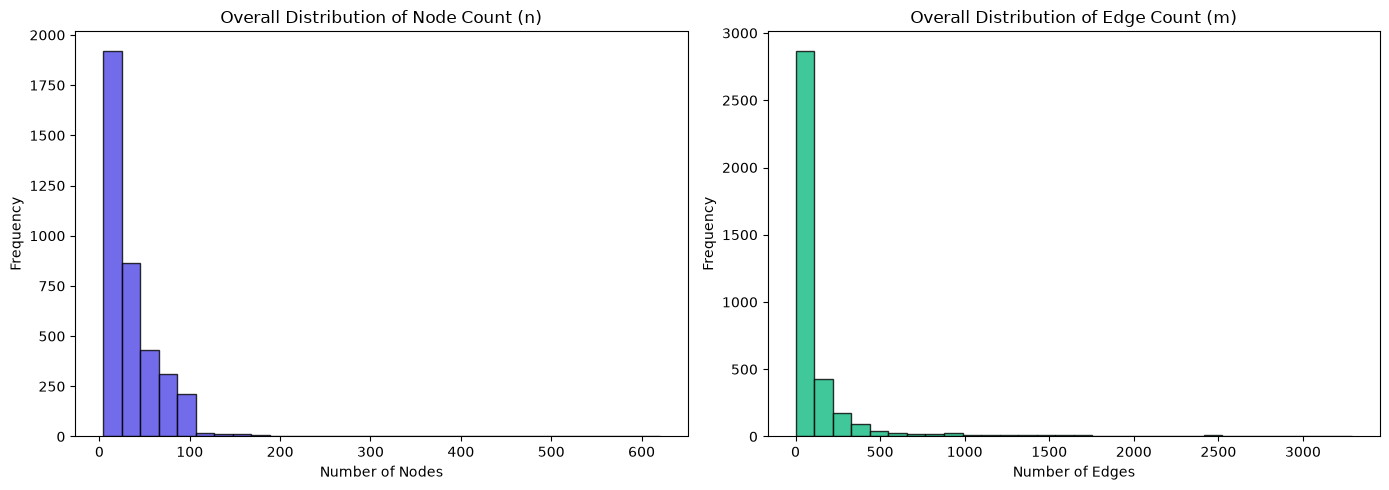

In [8]:
# Plotting overall distributions of nodes and edges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["num_nodes"], bins=30, color="#4F46E5", edgecolor="black", alpha=0.8)
axes[0].set_title("Overall Distribution of Node Count (n)")
axes[0].set_xlabel("Number of Nodes")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["num_edges"], bins=30, color="#10B981", edgecolor="black", alpha=0.8)
axes[1].set_title("Overall Distribution of Edge Count (m)")
axes[1].set_xlabel("Number of Edges")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "node_edge_distributions_overall.png"), dpi=150, bbox_inches="tight")
plt.show()

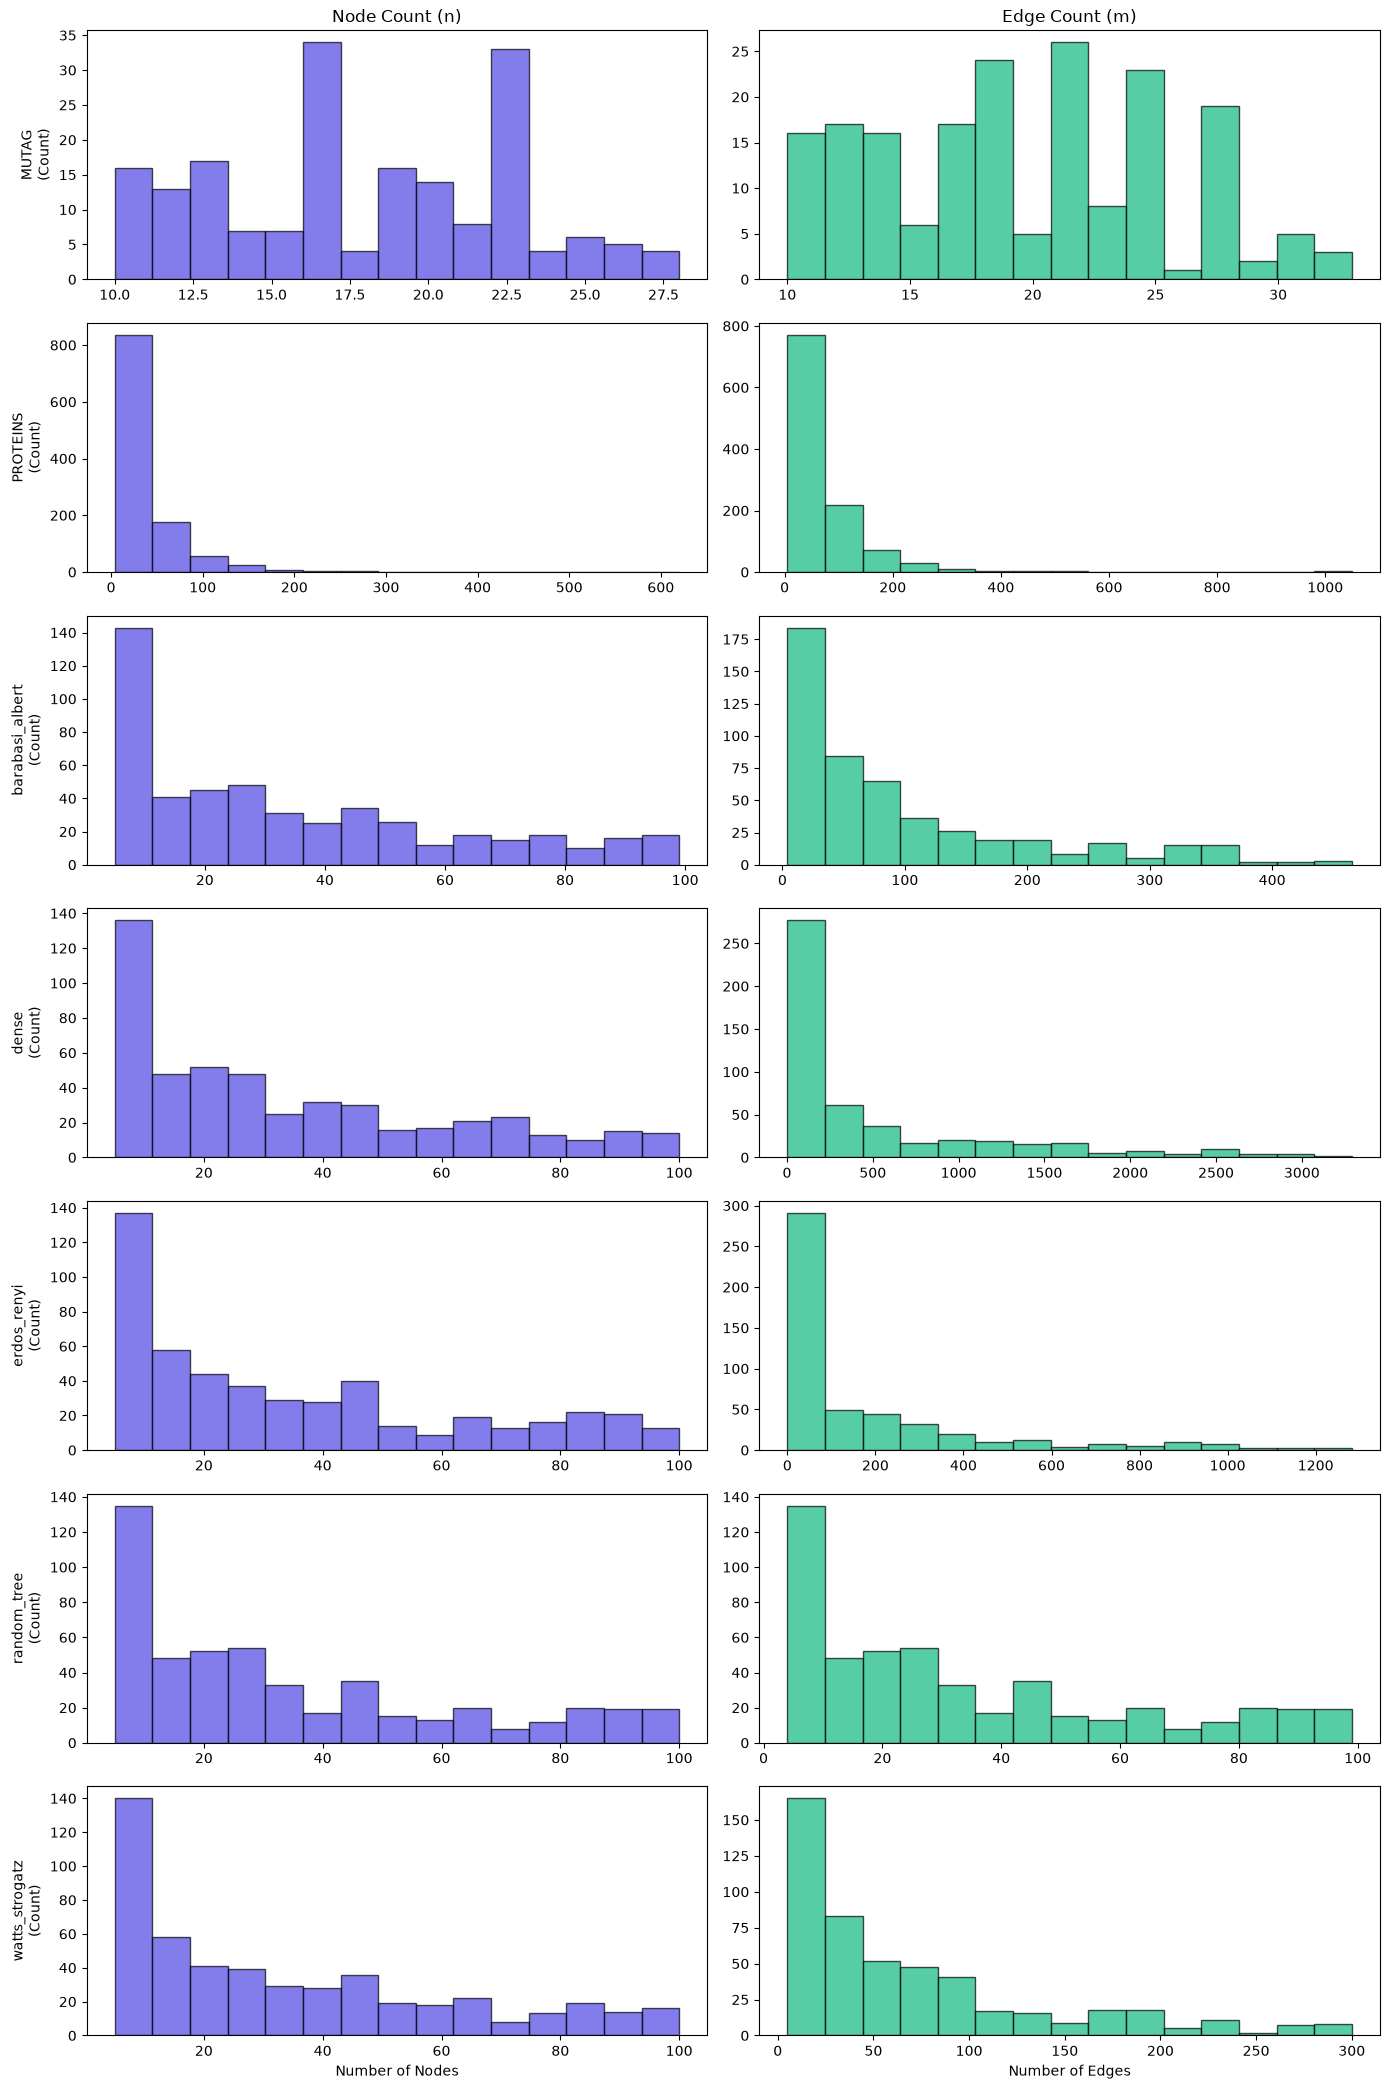

In [9]:
# Distributions per generator family
generators = df["generator"].unique()
fig, axes = plt.subplots(len(generators), 2, figsize=(14, 3 * len(generators)))

for idx, gen in enumerate(generators):
    gen_df = df[df["generator"] == gen]

    axes[idx, 0].hist(gen_df["num_nodes"], bins=15, color="#4F46E5", edgecolor="black", alpha=0.7)
    axes[idx, 0].set_ylabel(f"{gen}\n(Count)")
    if idx == 0:
        axes[idx, 0].set_title("Node Count (n)")
    if idx == len(generators) - 1:
        axes[idx, 0].set_xlabel("Number of Nodes")

    axes[idx, 1].hist(gen_df["num_edges"], bins=15, color="#10B981", edgecolor="black", alpha=0.7)
    if idx == 0:
        axes[idx, 1].set_title("Edge Count (m)")
    if idx == len(generators) - 1:
        axes[idx, 1].set_xlabel("Number of Edges")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "node_edge_distributions_by_generator.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Graph Counts per (Generator, Tier)

This bar chart inspects the representation of each node tier (tiny, small, medium, large, xlarge) across generators.

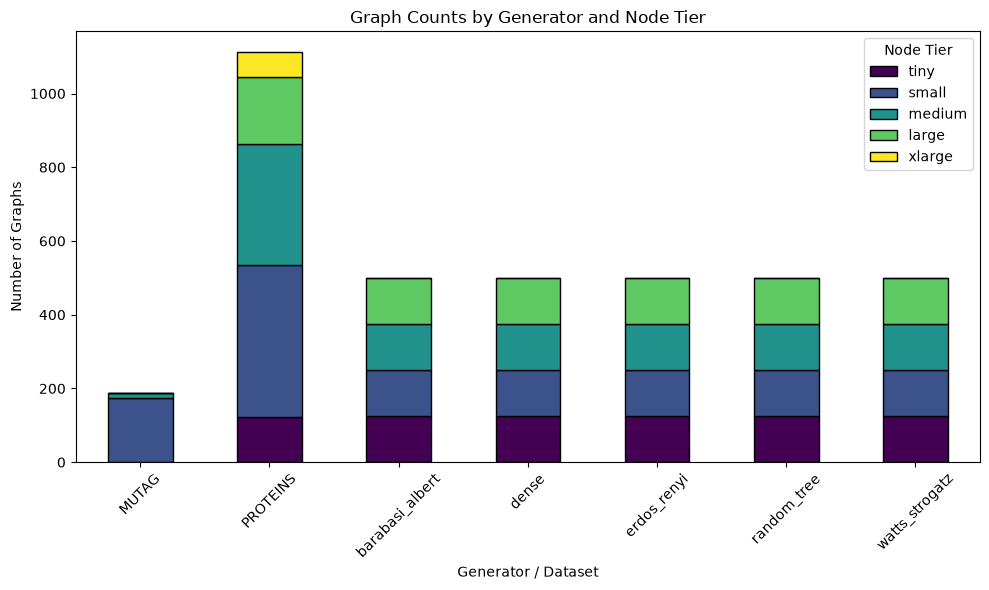

In [10]:
# Cross tabulate counts
crosstab = pd.crosstab(df["generator"], df["tier"])
tier_order = ["tiny", "small", "medium", "large", "xlarge"]
existing_tiers = [t for t in tier_order if t in crosstab.columns]
crosstab = crosstab[existing_tiers]

# Stacked bar chart
crosstab.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis", edgecolor="black")
plt.title("Graph Counts by Generator and Node Tier")
plt.xlabel("Generator / Dataset")
plt.ylabel("Number of Graphs")
plt.legend(title="Node Tier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "graph_counts_by_tier.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Visual Layout Inspections (Sample Render Grid)

We select 12 representative images spanning combinations of density, tier, and source to sanity-check visual aesthetics.

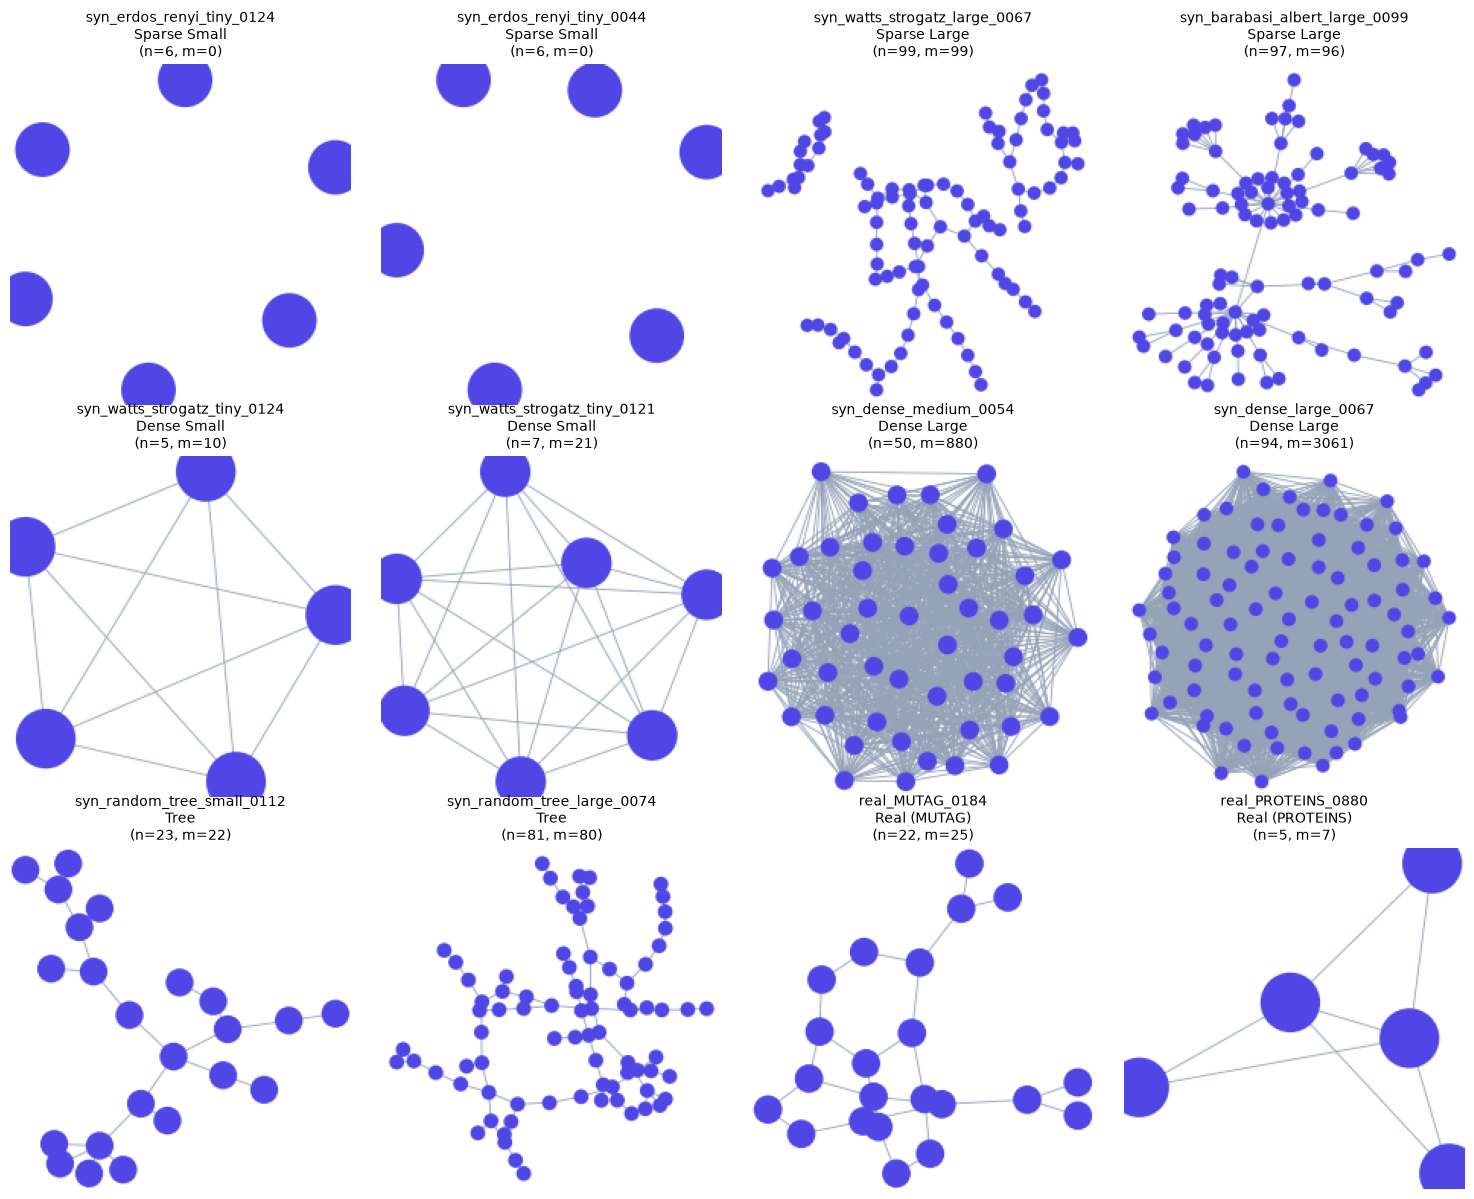

In [11]:
# Compute density for sorting
n_clipped = df["num_nodes"].clip(lower=2)
df["density"] = 2 * df["num_edges"] / (n_clipped * (n_clipped - 1))
samples = []

# 1. Sparse / Small
sparse_small = df[(df["source"] == "synthetic") & (df["num_nodes"] < 25)].sort_values("density").head(2)
for _, r in sparse_small.iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Sparse Small\n(n={r['num_nodes']}, m={r['num_edges']})"))

# 2. Sparse / Large
sparse_large = df[(df["source"] == "synthetic") & (df["num_nodes"] >= 50) & (df["generator"] != "random_tree")].sort_values("density").head(2)
for _, r in sparse_large.iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Sparse Large\n(n={r['num_nodes']}, m={r['num_edges']})"))

# 3. Dense / Small
dense_small = df[(df["source"] == "synthetic") & (df["num_nodes"] < 25)].sort_values("density", ascending=False).head(2)
for _, r in dense_small.iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Dense Small\n(n={r['num_nodes']}, m={r['num_edges']})"))

# 4. Dense / Large
dense_large = df[(df["source"] == "synthetic") & (df["num_nodes"] >= 50)].sort_values("density", ascending=False).head(2)
for _, r in dense_large.iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Dense Large\n(n={r['num_nodes']}, m={r['num_edges']})"))

# 5. Trees
trees = df[df["generator"] == "random_tree"].sample(2, random_state=42)
for _, r in trees.iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Tree\n(n={r['num_nodes']}, m={r['num_edges']})"))

# 6. Real graphs (MUTAG and PROTEINS)
mutag_sample = df[(df["source"] == "real") & (df["generator"] == "MUTAG")].sample(1, random_state=42)
proteins_sample = df[(df["source"] == "real") & (df["generator"] == "PROTEINS")].sample(1, random_state=42)
for _, r in pd.concat([mutag_sample, proteins_sample]).iterrows():
    samples.append((r["graph_id"], r["image_path"], f"Real ({r['generator']})\n(n={r['num_nodes']}, m={r['num_edges']})"))

# Plot the 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, (gid, img_path, desc) in enumerate(samples[:12]):
    actual_img_path = "../" + img_path
    if os.path.exists(actual_img_path):
        img = Image.open(actual_img_path)
        axes[idx].imshow(img)
    else:
        axes[idx].text(0.5, 0.5, "Image Not Found", ha='center', va='center')
    axes[idx].set_title(f"{gid}\n{desc}", fontsize=10)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_render_grid.png"), dpi=150, bbox_inches="tight")
plt.show()